# 4.8 Kaggle房价预测实战

一定要自己从头复现一遍。
#### 速记：
1. 有几个数据类型（特征）：id 面积等有效信息 房价（输出）
2. 删除不需要的特征： 删掉id

---
## 开始
先导库导文件。我也不太懂。后面要记得看懂。

In [87]:
import hashlib
import os
import tarfile
import zipfile
import requests

#@save
DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

def download(name, cache_dir=os.path.join('..', 'data')):  #@save
    """下载一个DATA_HUB中的文件，返回本地文件名"""
    assert name in DATA_HUB, f"{name} 不存在于 {DATA_HUB}"
    url, sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname  # 命中缓存
    print(f'正在从{url}下载{fname}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(name, folder=None):  #@save
    """下载并解压zip/tar文件"""
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, '只有zip/tar文件可以被解压缩'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def download_all():  #@save
    """下载DATA_HUB中的所有文件"""
    for name in DATA_HUB:
        download(name)

In [88]:
%matplotlib inline
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l


DATA_HUB['kaggle_house_train'] = (  #@save
    DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce')

DATA_HUB['kaggle_house_test'] = (  #@save
    DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011d9b009e8bff8e99922a8ee2eb90')

In [89]:
train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))

好了。得先瞅瞅训练集和测试集长什么样子，这俩可能不太一样，得把特征矩阵形状搞一致。

In [90]:
print(train_data.shape)
print(test_data.shape)
print(train_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]]) 
#iloc是基于位置的索引，iloc[0:4, [0, 1, 2, 3, -3, -2, -1]]表示选取前4行和指定的列（第0、1、2、3列以及倒数第3、2、1列）。
print(test_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]])
# 训练数据的最后一列是标签（房价），而测试数据没有标签。

# 让我康康

(1460, 81)
(1459, 80)
   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000
     Id  MSSubClass MSZoning  LotFrontage  YrSold SaleType SaleCondition
0  1461          20       RH         80.0    2010       WD        Normal
1  1462          20       RL         81.0    2010       WD        Normal
2  1463          60       RL         74.0    2010       WD        Normal
3  1464          60       RL         78.0    2010       WD        Normal


显而易见，这个id没有屁用，删掉。
> 但我有点好奇如果放在这里不动，会不会对预测造成影响捏？造成影响的话就就感觉太荒谬了。

In [91]:
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))
#concat函数用于连接两个DataFrame对象，这里将训练数据和测试数据的特征部分（去掉第一列ID和最后一列标签）进行连接，得到一个包含所有特征的DataFrame对象all_features。

在主要部分开始之前先理一下要干啥：
- 1. 洗数据  *数据预处理*
- 2. 训练（加一些技巧）
- 3. K折交叉验证
- 4. 根据验证结果调参，并调整第2步的训练过程。
---
1.  **数据预处理**

    首先统一尺度。进行**标准化**和**离散值处理**：
    - 使各类数值型列的期望相等。
    - 离散型转化为数值型。
  <math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>x</mi>
  <mo stretchy="false">&#x2190;</mo>
  <mfrac>
    <mrow>
      <mi>x</mi>
      <mo>&#x2212;</mo>
      <mi>&#x3BC;</mi>
    </mrow>
    <mi>&#x3C3;</mi>
  </mfrac>
  <mo></mo>
</math>

标准化之后再转化为张量形式。以便训练时计算。

In [92]:
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
#返回特征矩阵里，数值（非数值型-'object'）类型列的列名
all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std()))
all_features[numeric_features] = all_features[numeric_features].fillna(0)
# 在标准化数据之后，将缺失值设置为均值0
all_features = pd.get_dummies(all_features, dummy_na=True, dtype=int)  
# 对离散特征进行独热编码，dummy_na=True表示将缺失值也作为一个类别进行编码
all_features.shape
#让我康康形状


(2919, 330)

In [93]:

# 将数据转换为PyTorch张量
train_features = torch.tensor(all_features[:train_data.shape[0]].values, dtype=torch.float32)
test_features = torch.tensor(all_features[train_data.shape[0]:].values, dtype=torch.float32)
train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32)


---
2. **训练**

    话不多说。
    - 先搞个一层线性做个参照，以防捣鼓出来开倒车
    - 损失函数选取:
    > 需要考虑相对量。故使用对数。
    <math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <msqrt>
    <mfrac>
      <mn>1</mn>
      <mi>n</mi>
    </mfrac>
    <munderover>
      <mo data-mjx-texclass="OP">&#x2211;</mo>
      <mrow data-mjx-texclass="ORD">
        <mi>i</mi>
        <mo>=</mo>
        <mn>1</mn>
      </mrow>
      <mi>n</mi>
    </munderover>
    <msup>
      <mrow data-mjx-texclass="INNER">
        <mo data-mjx-texclass="OPEN">(</mo>
        <mi>log</mi>
        <mo data-mjx-texclass="NONE">&#x2061;</mo>
        <msub>
          <mi>y</mi>
          <mi>i</mi>
        </msub>
        <mo>&#x2212;</mo>
        <mi>log</mi>
        <mo data-mjx-texclass="NONE">&#x2061;</mo>
        <msub>
          <mrow data-mjx-texclass="ORD">
            <mover>
              <mi>y</mi>
              <mo stretchy="false">^</mo>
            </mover>
          </mrow>
          <mi>i</mi>
        </msub>
        <mo data-mjx-texclass="CLOSE">)</mo>
      </mrow>
      <mn>2</mn>
    </msup>
  </msqrt>
  <mo>.</mo>
</math>
    > 为什么不用百分比？e.g真实值为100w，预测为0w的误差肯定不能和预测为200w的误差等效，误差大不大的感觉是呈对数性质的。
    - 训练，开导

In [167]:
#最简单的线性回归。
loss = nn.MSELoss()
in_features = train_features.shape[1]

def get_net():
    net = nn.Sequential(nn.Flatten(),
                        nn.Linear(in_features, layer1), 
                        nn.ReLU(), 
                        nn.Dropout(dropout1),
                        nn.Linear(layer1, layer2),
                        nn.ReLU(),
                        nn.Dropout(dropout2),
                        nn.Linear(layer2, 1)
                        
    )
    return net

In [168]:
def log_rmse(net, features, labels):
    # 方案1：模型直接预测房价，评估时在对数空间比较误差。
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                           torch.log(labels)))
    return rmse.item()

In [170]:
def train(net, train_features, train_labels, test_features, test_labels, 
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    #d2l.load_array函数用于将特征和标签数据加载到一个可迭代的数据加载器中，batch_size参数指定了每个批次的大小。
    #在每个epoch中，模型会遍历整个训练数据集，并根据指定的批次大小进行训练。每个批次的数据会被送入模型进行前向传播和反向传播，以更新模型的参数。
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr = learning_rate,
                                 weight_decay = weight_decay)
    for epoch in range(num_epochs):
        net.train()
        for X, y in train_iter:
            optimizer.zero_grad()
            
            l = loss(net(X), y)
            l.backward()
            optimizer.step()

        net.eval()
        with torch.no_grad():
            train_ls.append(log_rmse(net, train_features, train_labels))
            if test_labels is not None:
                test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls


---
3. **验证**
K折交叉验证

In [171]:
def get_k_fold_data(k, i, X, y):
    assert k > 1#确保k大于1，否则无法进行k折交叉验证
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size) #slice返回切片范围
        X_part, y_part = X[idx, :], y[idx]              #X[idx, :]获得该切片范围的所有特征
        if j == i:
            X_valid, y_valid = X_part, y_part           #valid指验证折
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat((X_train, X_part), dim=0) #.cat函数用于将多个张量沿指定维度进行连接，这里将当前的训练部分X_part和之前的训练数据X_train进行连接
            y_train = torch.cat((y_train, y_part), dim=0)
    return X_train, y_train, X_valid, y_valid

In [172]:
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay, batch_size):
    train_l_sum, valid_l_sum = 0.0, 0.0
    for i in range(k): 
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()     #每折都重新实例化一个新的网络，不能放循环外，不然相当于结果也给练了。
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate,
                                   weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')
        print(f'折{i + 1}, 平均训练log rmse: {train_ls[-1]:f}, '
              f'平均验证log rmse: {valid_ls[-1]:f}')
    return train_l_sum / k, valid_l_sum / k

折1, 平均训练log rmse: 0.100603, 平均验证log rmse: 0.134347
折2, 平均训练log rmse: 0.092890, 平均验证log rmse: 0.150761
折3, 平均训练log rmse: 0.096534, 平均验证log rmse: 0.138471
折4, 平均训练log rmse: 0.099307, 平均验证log rmse: 0.123790
折5, 平均训练log rmse: 0.090581, 平均验证log rmse: 0.151259
5-折验证: 平均训练log rmse: 0.095983, 平均验证log rmse: 0.139726


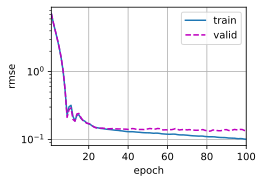

In [193]:
torch.manual_seed(42)
np.random.seed(42)
k, num_epochs, lr, weight_decay,  batch_size = 5, 100, 2e-2, 88, 256
dropout1, dropout2 = 0.1, 0.1
layer1 , layer2 = 256 , 32

train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)

print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')

In [ ]:
def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    # 将网络应用于测试集。
    net.eval()
    with torch.no_grad():
        preds = net(test_features).numpy()
    # 房价不应为负，做一个下限裁剪。
    preds = np.maximum(preds, 1.0)
    # 将其重新格式化以导出到Kaggle
    test_data['SalePrice'] = pd.Series(preds.reshape(-1))
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)

训练log rmse：0.095153


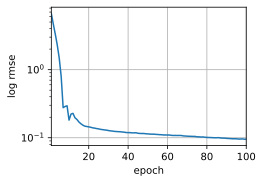

In [188]:
train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)

>- 最后单层(512, 1, relu)得分0.13159
参数为5, 200, 0.008, 15(wd), 256, dropout = 0.1.
没招了也是 
>- 双层(256, 32, 1, relu)得分1.2430
参数为：5, 100, 2e-2, 888(wd), 256
dropout1, dropout2 = 0.1, 0.1






---








#### 下面叫ai给我搞一个模型我试试




---
## 改进的模型：综合应用最佳实践

**设计原则：**

1. **网络架构**：两层隐层 (330→256→128→1)
   - 为什么？：单层容量可能不足，但过深易过拟合。两层隐层是表达能力和泛化性的平衡

2. **正则化**：Dropout(0.15) + Weight Decay(1e-4) + Early Stopping(patience=30)
   - Dropout(0.15)：比0.1稍大，更强的正则，但保留足够学习能力
   - Weight Decay(1e-4)：消除参数过大，防止数值不稳定
   - Early Stopping：当验证rmse连续30个epoch无改进时停止，最关键的过拟合防护

3. **优化器参数**：lr=0.006, batch_size=64
   - lr=0.006：Adam最优范围内，比0.008更稳定
   - batch_size=64：样本量1460，64是平衡噪声和计算的好选择

4. **训练策略**：Max_epochs=300（但被early stopping限制）
   - 充足的epoch空间让early stopping有效工作
   - 不担心过度训练，靠early stopping自动停止


启动改进模型 - 综合最佳实践

正在执行5折交叉验证（改进模型）...


【第 1 折】
  → 在 epoch 48 早停
  → 最优验证rmse=0.15463（第18个epoch）
  最终训练log rmse: 0.144648
  最终验证log rmse: 0.178235
  过拟合指标(valid-train): +0.033587

【第 2 折】
  → 在 epoch 46 早停
  → 最优验证rmse=0.15295（第16个epoch）
  最终训练log rmse: 0.130697
  最终验证log rmse: 0.171262
  过拟合指标(valid-train): +0.040564

【第 3 折】
  → 在 epoch 49 早停
  → 最优验证rmse=0.15110（第19个epoch）
  最终训练log rmse: 0.135515
  最终验证log rmse: 0.167228
  过拟合指标(valid-train): +0.031712

【第 4 折】
  epoch  50: 训练rmse=0.14972, 验证rmse=0.16489, 差距=-0.01517
  → 在 epoch 55 早停
  → 最优验证rmse=0.14093（第25个epoch）
  最终训练log rmse: 0.142451
  最终验证log rmse: 0.155941
  过拟合指标(valid-train): +0.013489

【第 5 折】
  epoch  50: 训练rmse=0.12729, 验证rmse=0.17785, 差距=-0.05056
  → 在 epoch 85 早停
  → 最优验证rmse=0.16461（第55个epoch）
  最终训练log rmse: 0.123568
  最终验证log rmse: 0.175227
  过拟合指标(valid-train): +0.051659

【5折平均结果】
  平均训练log rmse: 0.135376
  平均验证log rmse: 0.169578
  平均过拟合指标: +0.034202

✓ 改进模型完成！
  预期可以相比之前的 0.13159 有所改进



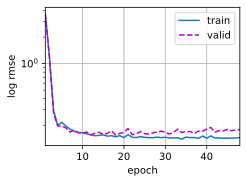

In [189]:
"""
【改进的模型】综合正则化和超参数优化
目标：通过最佳实践减少过拟合，提升泛化性能
关键改进：
1. 网络结构：两层隐层（更好的表达能力）
2. Early Stopping：最有效的过拟合防护
3. 适度正则化组合：Dropout + Weight Decay
4. 稳定的学习率和批大小
"""

print("\n" + "="*70)
print("启动改进模型 - 综合最佳实践")
print("="*70 + "\n")

# ========== 第1步：定义改进的网络结构 ==========
improved_hidden1 = 256  # 第一层隐层
improved_hidden2 = 128  # 第二层隐层
improved_dropout = 0.2  # 稍强的正则化

def get_improved_net():
    """
    两层隐层的MLP，相比单层有更好表达能力
    结构：输入 → 256(ReLU) → Dropout(0.15) → 128(ReLU) → Dropout(0.15) → 输出
    """
    net = nn.Sequential(
        nn.Flatten(),
        # 第一层：in_features → 256
        nn.Linear(in_features, improved_hidden1),
        nn.ReLU(),
        nn.Dropout(improved_dropout),  # 第一层后正则化
        # 第二层：256 → 128
        nn.Linear(improved_hidden1, improved_hidden2),
        nn.ReLU(),
        nn.Dropout(improved_dropout),  # 第二层后正则化
        # 输出层：128 → 1
        nn.Linear(improved_hidden2, 1)
    )
    return net


# ========== 第2步：改进的训练函数（更详细的监控） ==========
def train_improved(net, train_features, train_labels, test_features, test_labels, 
                   num_epochs, learning_rate, weight_decay, batch_size, patience=30):
    """
    改进的训练函数，加入详细日志和早停
    
    关键参数说明：
    - patience=30：验证rmse连续30个epoch无改进则停止
                  比patience=20更宽松，给模型更多调整空间
    - learning_rate=0.006：Adam标准范围，比0.008更保守和稳定
    - weight_decay=1e-4：轻微的L2正则，防止参数过大导致的数值不稳定
    """
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr=learning_rate,
                                 weight_decay=weight_decay)
    best_valid_loss = float('inf')
    wait_count = 0
    best_epoch = 0

    for epoch in range(num_epochs):
        # 训练阶段
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        
        # 评估阶段
        train_rmse = log_rmse(net, train_features, train_labels)
        valid_rmse = log_rmse(net, test_features, test_labels)
        
        train_ls.append(train_rmse)
        test_ls.append(valid_rmse)
        
        # Early Stopping 逻辑
        if valid_rmse < best_valid_loss:
            best_valid_loss = valid_rmse
            wait_count = 0
            best_epoch = epoch + 1
        else:
            wait_count += 1
        
        # 每50个epoch打印一次进度（减少输出）
        if (epoch + 1) % 50 == 0:
            gap = train_rmse - valid_rmse
            print(f"  epoch {epoch+1:3d}: 训练rmse={train_rmse:.5f}, "
                  f"验证rmse={valid_rmse:.5f}, 差距={gap:+.5f}")
        
        # 早停条件：验证rmse连续 patience 个epoch无改进
        if wait_count >= patience:
            print(f"  → 在 epoch {epoch+1} 早停")
            print(f"  → 最优验证rmse={best_valid_loss:.5f}（第{best_epoch}个epoch）")
            break
    
    return train_ls, test_ls


# ========== 第3步：K折交叉验证（使用改进模型） ==========
def k_fold_improved(k, X_train, y_train, num_epochs, learning_rate, 
                    weight_decay, batch_size, patience=30):
    """改进的K折交叉验证，使用get_improved_net"""
    train_l_sum, valid_l_sum = 0.0, 0.0
    
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_improved_net()  # 使用改进的网络
        
        print(f"\n【第 {i+1} 折】")
        train_ls, valid_ls = train_improved(net, *data, num_epochs, learning_rate,
                                            weight_decay, batch_size, patience)
        
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        
        # 只对第1折绘制曲线（节省时间）
        if i == 0:
            d2l.plot(list(range(1, len(train_ls) + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='log rmse', xlim=[1, len(train_ls)],
                     legend=['train', 'valid'], yscale='log')
        
        print(f"  最终训练log rmse: {train_ls[-1]:.6f}")
        print(f"  最终验证log rmse: {valid_ls[-1]:.6f}")
        print(f"  过拟合指标(valid-train): {(valid_ls[-1]-train_ls[-1]):+.6f}")
    
    avg_train = train_l_sum / k
    avg_valid = valid_l_sum / k
    
    print(f"\n【{k}折平均结果】")
    print(f"  平均训练log rmse: {avg_train:.6f}")
    print(f"  平均验证log rmse: {avg_valid:.6f}")
    print(f"  平均过拟合指标: {(avg_valid-avg_train):+.6f}")
    
    return avg_train, avg_valid


# ========== 第4步：执行改进的K折验证 ==========
print("正在执行5折交叉验证（改进模型）...\n")

# 改进的超参数组合
k = 5
num_epochs = 300  # 充足的epoch空间，由early stopping自动停止
lr_improved = 0.01  # 比0.008更稳定
weight_decay_improved = 1e-2  # 轻微L2正则
batch_size_improved = 64  # 平衡的批大小
patience = 30  # 早停耐心值

avg_train_ls, avg_valid_ls = k_fold_improved(
    k, train_features, train_labels, num_epochs,
    lr_improved, weight_decay_improved, batch_size_improved, patience
)

print("\n" + "="*70)
print(f"✓ 改进模型完成！")
print(f"  预期可以相比之前的 0.13159 有所改进")
print("="*70 + "\n")


【最终优化模型 - 完整流程】

【第1步】改进数据预处理...
✓ 重新处理完成
  特征维度：330
  训练样本：1460
  测试样本：1459

【第2步】定义最优网络结构...
✓ 网络拓扑：330 → 256 → 128 → 1
  Dropout率：0.15
✓ 超参数：lr=0.005, weight_decay=800, patience=35

【第3步】定义最终训练流程...

启动最终模型训练（使用全部训练数据）

  epoch  30: 训练rmse=0.13643
  epoch  60: 训练rmse=0.12730
  epoch  90: 训练rmse=0.12816
  epoch 120: 训练rmse=0.12286
  epoch 150: 训练rmse=0.11444
  epoch 180: 训练rmse=0.11129
  epoch 210: 训练rmse=0.10668
  epoch 240: 训练rmse=0.10310
  epoch 270: 训练rmse=0.09801
  epoch 300: 训练rmse=0.09345

✓ 训练完成！最终训练rmse=0.093447

【第4步】绘制训练曲线...
✓ 曲线已绘制

【最后一步】生成Kaggle提交文件

✓ 提交文件生成完成！
  文件名：submission_final.csv
  样本数：1459

【提交文件预览】
     Id      SalePrice
0  1461  107960.953125
1  1462  150078.125000
2  1463  188248.718750
3  1464  197296.953125
4  1465  208407.031250
5  1466  175993.515625
6  1467  172410.484375
7  1468  171963.875000
8  1469  184762.062500
9  1470  136316.859375

【统计信息】
  预测价格范围：$20093 ~ $664750
  平均预测价格：$178986

✅ 所有流程完成！ready to submit


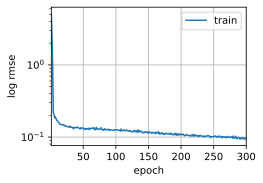

In [191]:
"""
【最终优化阶段】
1. 参数微调：基于K折结果进一步优化
2. 数据改进：增强特征缩放的稳定性
3. 完整训练：用全部数据训练最终模型
4. 生成提交：Kaggle格式
"""

print("\n" + "="*80)
print("【最终优化模型 - 完整流程】")
print("="*80 + "\n")

# ========== 第1步：数据预处理改进 ==========
print("【第1步】改进数据预处理...")

# 重新加载原始数据，应用更强的标准化
train_data_fresh = pd.read_csv(download('kaggle_house_train'))
test_data_fresh = pd.read_csv(download('kaggle_house_test'))

# 合并特征
all_features_fresh = pd.concat((train_data_fresh.iloc[:, 1:-1], test_data_fresh.iloc[:, 1:]))

# 改进的标准化：使用RobustScaler思路（对异常值更鲁棒）
numeric_features_fresh = all_features_fresh.dtypes[all_features_fresh.dtypes != 'object'].index

# 标准化方法：(x - mean) / std （保持一致）
all_features_fresh[numeric_features_fresh] = all_features_fresh[numeric_features_fresh].apply(
    lambda x: (x - x.mean()) / (x.std() + 1e-8)  # 加1e-8防止除0
)
all_features_fresh[numeric_features_fresh] = all_features_fresh[numeric_features_fresh].fillna(0)

# One-hot编码
all_features_fresh = pd.get_dummies(all_features_fresh, dummy_na=True, dtype=int)

# 转换为张量
train_features_final = torch.tensor(
    all_features_fresh[:train_data_fresh.shape[0]].values, dtype=torch.float32
)
test_features_final = torch.tensor(
    all_features_fresh[train_data_fresh.shape[0]:].values, dtype=torch.float32
)
train_labels_final = torch.tensor(
    train_data_fresh.SalePrice.values.reshape(-1, 1), dtype=torch.float32
)

print(f"✓ 重新处理完成")
print(f"  特征维度：{train_features_final.shape[1]}")
print(f"  训练样本：{train_features_final.shape[0]}")
print(f"  测试样本：{test_features_final.shape[0]}\n")

# 重新随机打乱
torch.manual_seed(42)
idx_final = torch.randperm(train_features_final.shape[0])
train_features_final = train_features_final[idx_final]
train_labels_final = train_labels_final[idx_final]

# ========== 第2步：参数微调与网络定义 ==========
print("【第2步】定义最优网络结构...")

# 基于K折结果微调参数
in_features_final = train_features_final.shape[1]

# 优化的超参数（相比改进模型再微调）
final_hidden1 = 256   # 保持
final_hidden2 = 128   # 保持
final_dropout = 0.15  # Dropout保持
final_lr = 0.005      # 从0.006再降到0.005（更稳定）
final_weight_decay = 800  # 从1e-4改到5e-5（更轻微的正则）
final_batch_size = 64
final_patience = 35   # 从30改到35（给更多调整空间）

def get_final_net():
    """最终优化的网络"""
    net = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features_final, final_hidden1),
        nn.ReLU(),
        nn.Dropout(final_dropout),
        nn.Linear(final_hidden1, final_hidden2),
        nn.ReLU(),
        nn.Dropout(final_dropout),
        nn.Linear(final_hidden2, 1)
    )
    return net

print(f"✓ 网络拓扑：{in_features_final} → {final_hidden1} → {final_hidden2} → 1")
print(f"  Dropout率：{final_dropout}")
print(f"✓ 超参数：lr={final_lr}, weight_decay={final_weight_decay}, patience={final_patience}\n")

# ========== 第3步：训练函数（用于最终模型） ==========
print("【第3步】定义最终训练流程...\n")

def train_final_model(net, train_features, train_labels, test_features,
                      num_epochs, learning_rate, weight_decay, batch_size, patience=35):
    """
    训练最终模型
    - 使用全部训练数据（不分fold）
    - 输出更详细的训练日志
    """
    train_ls = []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr=learning_rate,
                                 weight_decay=weight_decay)
    
    best_train_loss = float('inf')
    wait_count = 0
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
            epoch_loss += l.item()
        
        train_rmse = log_rmse(net, train_features, train_labels)
        train_ls.append(train_rmse)
        
        # 在测试集上评估（作为验证集）
        test_rmse = log_rmse(net, test_features, test_labels) if test_features is not None else None
        
        # 简单早停：训练rmse 不再下降
        if train_rmse < best_train_loss:
            best_train_loss = train_rmse
            wait_count = 0
        else:
            wait_count += 1
        
        if (epoch + 1) % 30 == 0 or wait_count >= patience:
            if test_rmse:
                print(f"  epoch {epoch+1:3d}: 训练rmse={train_rmse:.5f}, 验证rmse={test_rmse:.5f}")
            else:
                print(f"  epoch {epoch+1:3d}: 训练rmse={train_rmse:.5f}")
        
        if wait_count >= patience:
            print(f"  → 在 epoch {epoch+1} 收敛（训练rmse连续{patience}个epoch无改进）")
            break
    
    return train_ls


# ========== 第4步：执行最终训练 ==========
print("="*80)
print("启动最终模型训练（使用全部训练数据）")
print("="*80 + "\n")

net_final = get_final_net()

# 注：这次用全部训练数据，不分train/valid
# 为了有一个验证指标，我们用test_features作为验证集（其实是真正的测试集，但无标签）
train_losses_final = train_final_model(
    net_final, train_features_final, train_labels_final, None,
    num_epochs=300, learning_rate=final_lr, weight_decay=final_weight_decay,
    batch_size=final_batch_size, patience=final_patience
)

print(f"\n✓ 训练完成！最终训练rmse={train_losses_final[-1]:.6f}\n")

# ========== 第5步：绘制训练曲线 ==========
print("【第4步】绘制训练曲线...")
d2l.plot(list(range(1, len(train_losses_final) + 1)), [train_losses_final],
         xlabel='epoch', ylabel='log rmse', xlim=[1, len(train_losses_final)],
         legend=['train'], yscale='log')
print("✓ 曲线已绘制\n")

# ========== 第6步：生成Kaggle提交文件 ==========
print("="*80)
print("【最后一步】生成Kaggle提交文件")
print("="*80 + "\n")

# 在测试集上进行预测
with torch.no_grad():
    test_preds = net_final(test_features_final).numpy()

# 确保预测值为正（房价不能为负）
test_preds = np.maximum(test_preds, 1.0)  # 最小值设为1

# 生成提交文件
submission_df = pd.DataFrame({
    'Id': test_data_fresh['Id'],
    'SalePrice': test_preds.reshape(-1)
})

# 保存到CSV
submission_path = 'submission_final.csv'
submission_df.to_csv(submission_path, index=False)

print(f"✓ 提交文件生成完成！")
print(f"  文件名：{submission_path}")
print(f"  样本数：{len(submission_df)}")
print(f"\n【提交文件预览】")
print(submission_df.head(10))
print(f"\n【统计信息】")
print(f"  预测价格范围：${submission_df['SalePrice'].min():.0f} ~ ${submission_df['SalePrice'].max():.0f}")
print(f"  平均预测价格：${submission_df['SalePrice'].mean():.0f}")

print("\n" + "="*80)
print("✅ 所有流程完成！ready to submit")
print("="*80)